# 02 · Training baseline

Capstone Project Module 4, hari 3. Notebook ini menghasilkan **satu model
baseline yang seadanya**, bukan model terbaik.

Tujuannya bukan mengejar mAP. Tujuannya menghasilkan berkas `best.pt` secepat
mungkin supaya jalur sampai deploy bisa dibuktikan hari ini juga, saat masih ada
dua belas hari untuk memperbaiki. Pengejaran mAP dilakukan hari 8 sampai 10 di
notebook yang sama, dengan tabel eksperimen.

**Wajib pakai GPU.** Menu Runtime, Change runtime type, pilih T4 GPU, Save.

Prasyarat, zip dataset sudah diunggah ke Google Drive di `MyDrive/capstone4/`.

In [5]:
!nvidia-smi -L || echo "TIDAK ADA GPU. Runtime, Change runtime type, T4 GPU."
!pip install -q ultralytics

GPU 0: Tesla T4 (UUID: GPU-403f8472-7664-1655-2b0b-da4faa0da1bf)


In [6]:
import os, glob, json, shutil, zipfile, time
import ultralytics, torch, yaml
from ultralytics import YOLO

print("ultralytics", ultralytics.__version__)
print("torch      ", torch.__version__)
print("GPU        ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "TIDAK ADA")
print()
print("CATAT DUA ANGKA DI ATAS. Versi ultralytics wajib sama persis di")
print("requirements.txt aplikasi, karena berkas bobot menyimpan referensi")
print("ke kelas Python di dalam library.")

ultralytics 8.4.138
torch       2.11.0+cu128
GPU         Tesla T4

CATAT DUA ANGKA DI ATAS. Versi ultralytics wajib sama persis di
requirements.txt aplikasi, karena berkas bobot menyimpan referensi
ke kelas Python di dalam library.


## Menyiapkan dataset

Dataset disalin dari Drive ke penyimpanan lokal Colab lebih dulu. Membaca ribuan
berkas kecil lewat mount Drive jauh lebih lambat daripada dari disk lokal.

In [7]:
ZIP_DRIVE = "/content/drive/MyDrive/capstone4/construction safety.v1i.yolov12.zip"
ROOT = "/content/dataset"

if not os.path.isdir(ROOT):
    if not os.path.exists(ZIP_DRIVE):
        from google.colab import drive
        drive.mount("/content/drive")
    assert os.path.exists(ZIP_DRIVE), f"Zip tidak ada di {ZIP_DRIVE}"
    shutil.copy(ZIP_DRIVE, "/content/data.zip")        # salin dulu, jangan baca dari mount
    with zipfile.ZipFile("/content/data.zip") as z:
        z.extractall(ROOT)

YAML = glob.glob(f"{ROOT}/*.yaml")[0]
cfg = yaml.safe_load(open(YAML))

# Roboflow menulis path relatif seperti ../train/images. Ditulis ulang menjadi
# absolut supaya tidak bergantung pada direktori kerja saat training.
for k, sub in [("train", "train"), ("val", "valid"), ("test", "test")]:
    cfg[k] = f"{ROOT}/{sub}/images"
with open(YAML, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)

NAMES = cfg["names"] if isinstance(cfg["names"], list) else list(cfg["names"].values())
print(open(YAML).read())
print("kelas:", {i: n for i, n in enumerate(NAMES)})
for s in ["train", "valid", "test"]:
    print(f"  {s:6} {len(glob.glob(f'{ROOT}/{s}/images/*')):5d} gambar")

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images
nc: 5
names:
- helmet
- no-helmet
- no-vest
- person
- vest
roboflow:
  workspace: personal-project-kej16
  project: construction-safety-gsnvb-jl6el
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/construction-safety-gsnvb-jl6el/dataset/1

kelas: {0: 'helmet', 1: 'no-helmet', 2: 'no-vest', 3: 'person', 4: 'vest'}
  train    997 gambar
  valid    119 gambar
  test      90 gambar


## Konfigurasi training

Tiap kelompok argumen punya alasan, dan alasannya ditulis supaya bisa dijelaskan
di video.

### Kenapa augmentasi geometris dimatikan semua

Dokumen SOAL meminta augmentasi yang **tidak mengubah geometris gambar**.
Ultralytics menyalakan **empat** augmentasi geometris secara default,
`fliplr=0.5`, `mosaic=1.0`, `scale=0.5`, `translate=0.1`. Menghapus satu baris
`flipud` tidak cukup, keempatnya harus dimatikan eksplisit.

Trade-off-nya dinyatakan terbuka. Mematikan mosaic biasanya **menurunkan** mAP
pada dataset kecil, karena mosaic salah satu augmentasi paling efektif di YOLO.
Penurunan itu diterima demi kepatuhan pada instruksi. Hari 8 sampai 10 kedua
versinya dilatih supaya selisihnya bisa ditunjukkan dengan angka.

### Kenapa fotometrik dipertahankan

EDA hari 2 menemukan 7,6 persen gambar menyimpang pencahayaannya, 24 gelap dan
68 terang berlebih. Ditangani lewat augmentasi `hsv_v`, bukan lewat preprocessing
tetap seperti CLAHE, supaya tidak ada langkah yang harus diingat saat inference.

### Kenapa imgsz 640 dulu

EDA menunjukkan 32,6 persen `helmet` berada di bawah 32 piksel pada 640, dan
turun ke 14,1 persen pada 960. Itu alasan kuat untuk menaikkan resolusi, tapi
biayanya sekitar 2,25 kali lebih lama. Hari ini yang dikejar kecepatan sampai
deploy, jadi 640 dulu, 960 jadi pembanding di hari 8 sampai 10.

In [8]:
MODEL_AWAL = "yolo11n.pt"     # varian nano, sekitar 5 MB, muat di hosting gratis
RUN = "v1_baseline_640"
PROJECT = "/content/runs_capstone"

model = YOLO(MODEL_AWAL)     # transfer learning dari checkpoint COCO

t0 = time.time()
hasil = model.train(
    # data dan durasi, sengaja pendek untuk baseline
    data=YAML,
    epochs=30,
    patience=10,

    # skala
    imgsz=640,
    batch=16,

    # supaya bisa diulang dan run tidak saling menimpa
    seed=0,
    deterministic=True,
    project=PROJECT,
    name=RUN,
    exist_ok=False,
    val=True,
    plots=True,

    # AUGMENTASI GEOMETRIS DIMATIKAN, mengikuti anjuran SOAL.
    # Empat di antaranya aktif secara default, bukan hanya flipud.
    fliplr=0.0, flipud=0.0, degrees=0.0, shear=0.0,
    perspective=0.0, translate=0.0, scale=0.0,
    mosaic=0.0, mixup=0.0, cutmix=0.0, copy_paste=0.0,

    # Fotometrik dipertahankan, sesuai anjuran SOAL.
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    erasing=0.4,      # random erasing, occlusion bukan geometri
)
print(f"\nwaktu training {(time.time()-t0)/60:.1f} menit")

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=v1_baseline_640, nbs=64, nms=False, 

In [9]:
# Verifikasi bahwa augmentasi geometris benar-benar mati.
# Jangan percaya kode, percaya args.yaml yang ditulis Ultralytics.
args = yaml.safe_load(open(f"{PROJECT}/{RUN}/args.yaml"))
GEO = ["fliplr","flipud","degrees","shear","perspective","translate","scale",
       "mosaic","mixup","copy_paste"]
FOTO = ["hsv_h","hsv_s","hsv_v","erasing"]

print("geometris, semua harus 0.0")
for k in GEO:
    v = args.get(k, "tidak ada")
    print(f"  {k:14} {v}" + ("" if v in (0, 0.0) else "   <- MASIH AKTIF"))
print("\nfotometrik, dipertahankan")
for k in FOTO:
    print(f"  {k:14} {args.get(k)}")

assert all(args.get(k) in (0, 0.0) for k in GEO), "ada augmentasi geometris yang masih aktif"
print("\nverifikasi lolos")

geometris, semua harus 0.0
  fliplr         0.0
  flipud         0.0
  degrees        0.0
  shear          0.0
  perspective    0.0
  translate      0.0
  scale          0.0
  mosaic         0.0
  mixup          0.0
  copy_paste     0.0

fotometrik, dipertahankan
  hsv_h          0.015
  hsv_s          0.7
  hsv_v          0.4
  erasing        0.4

verifikasi lolos


## Membaca hasil training

Empat berkas yang menjawab pertanyaan "model saya kenapa".


results.png


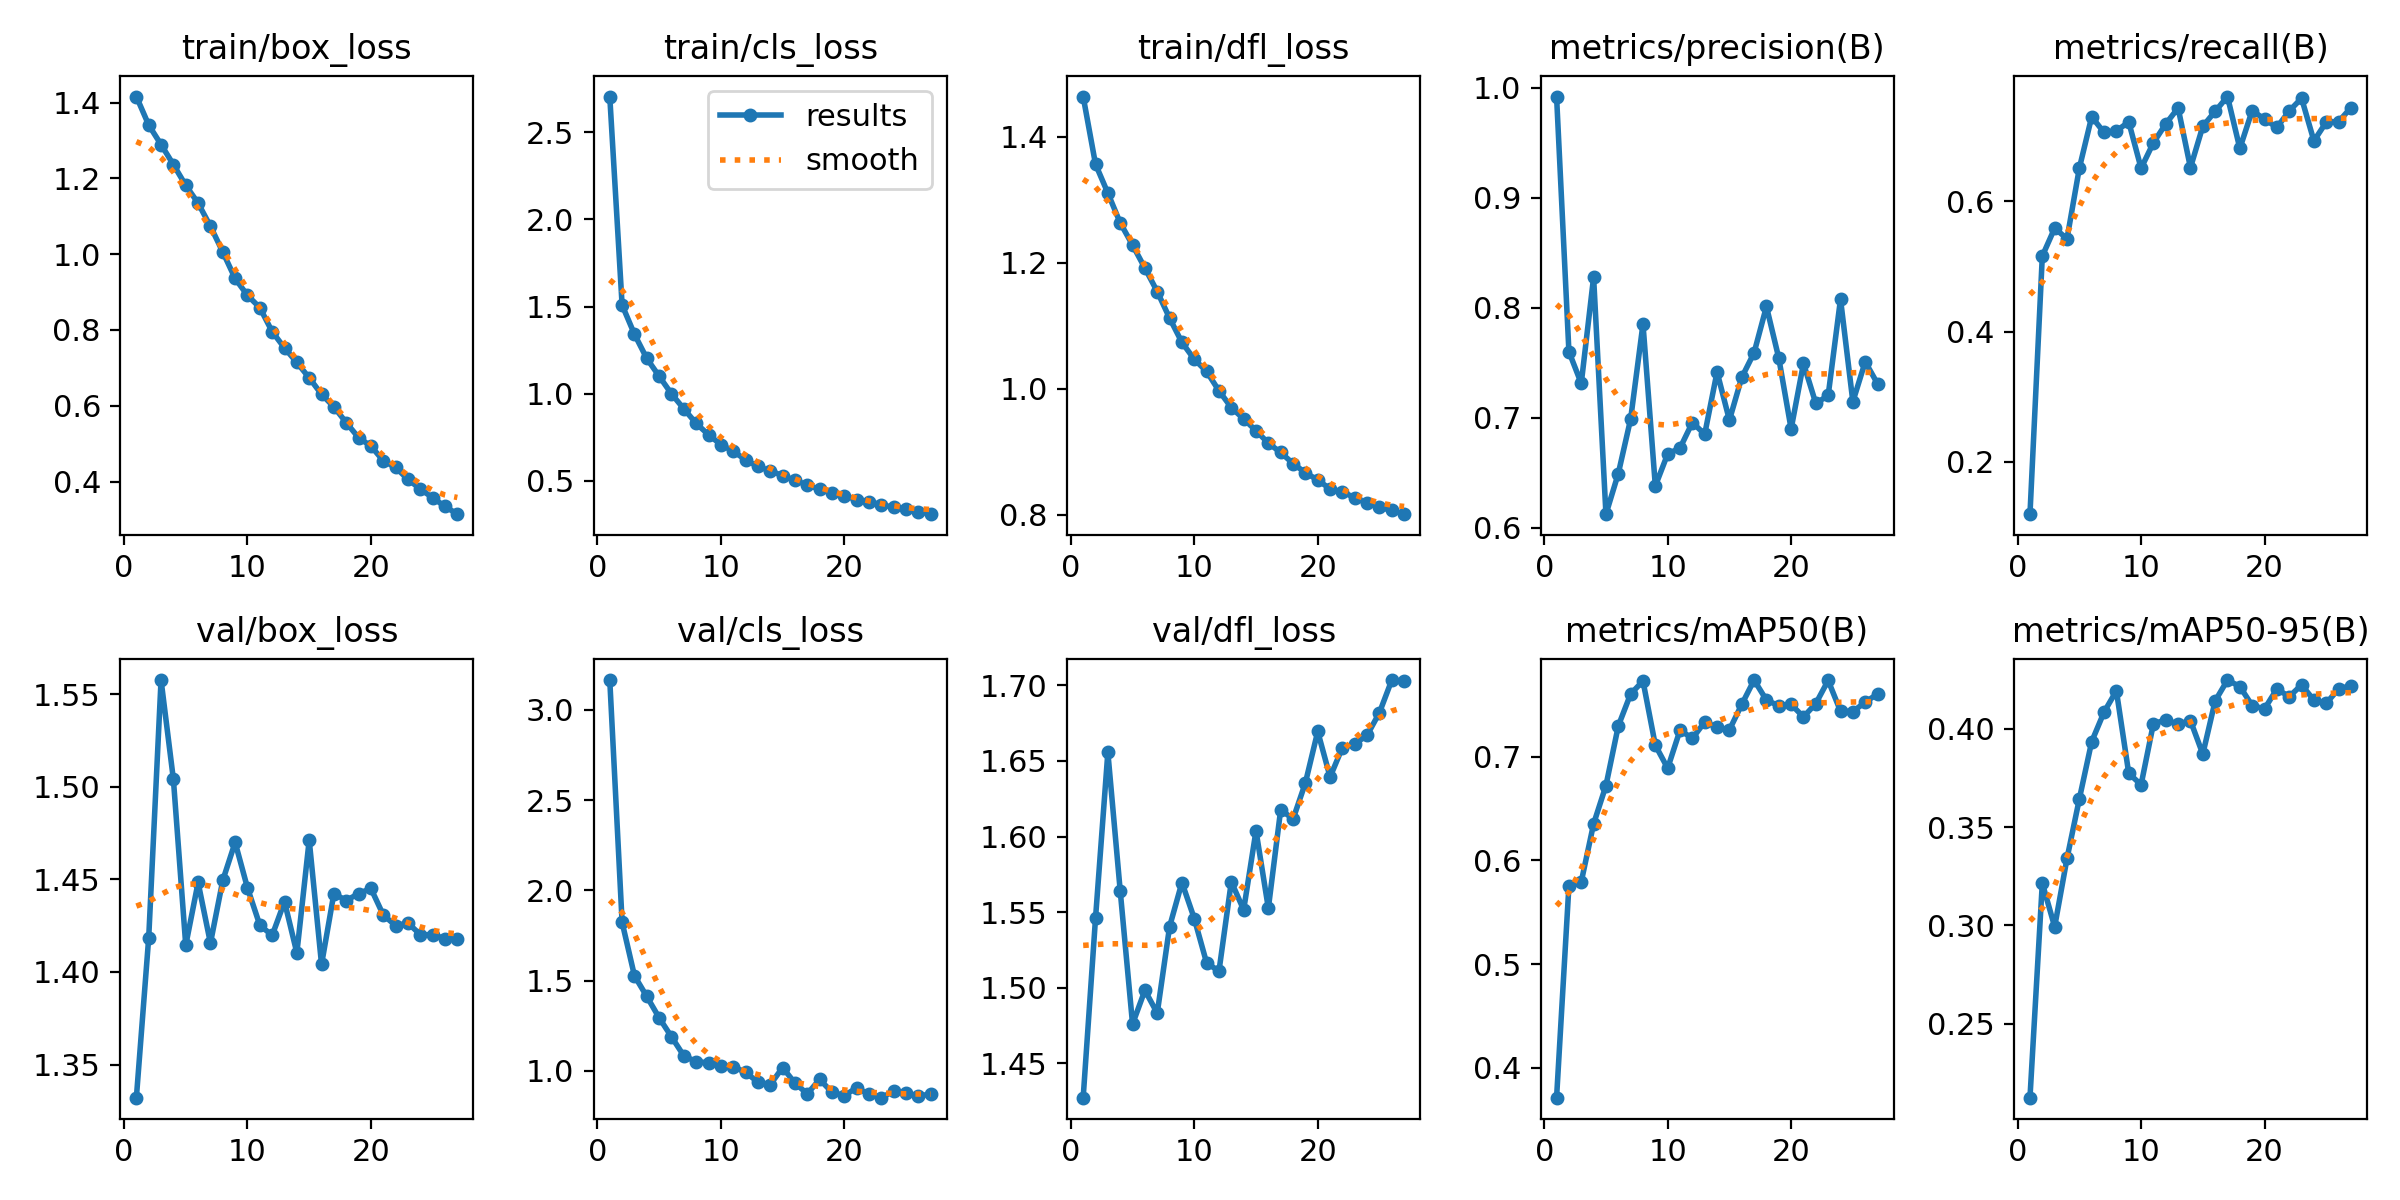


confusion_matrix_normalized.png


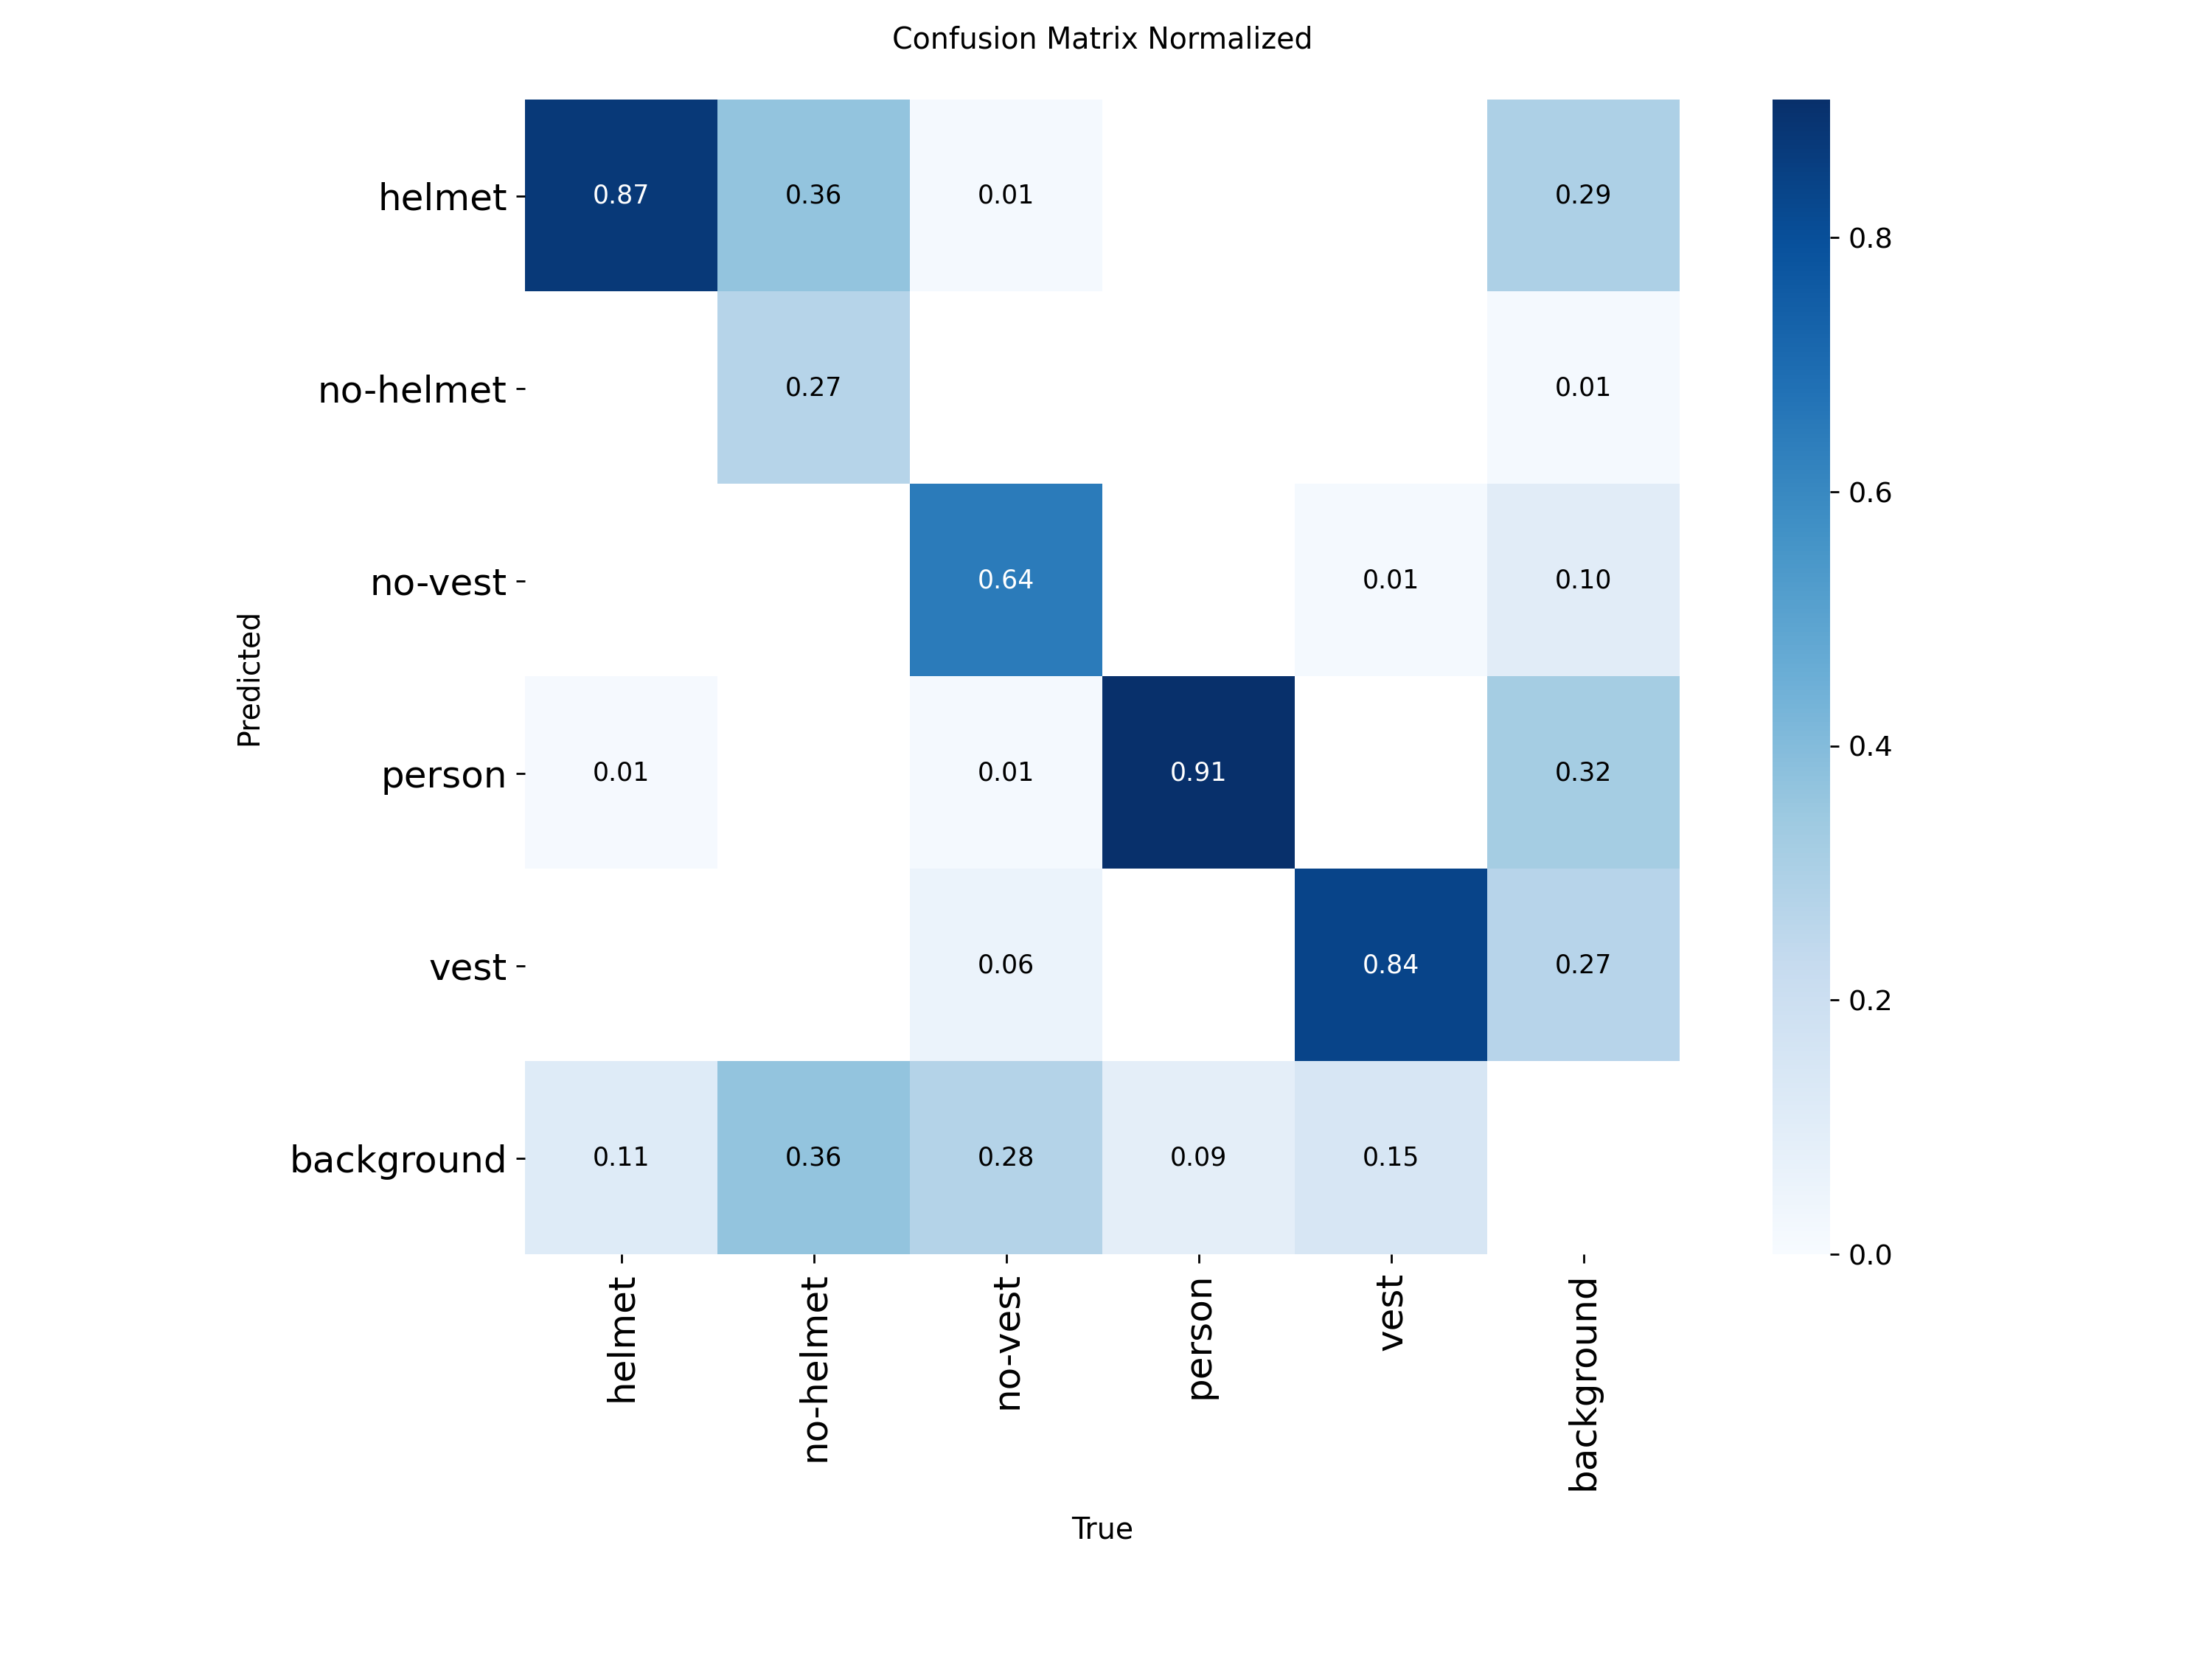


BoxPR_curve.png


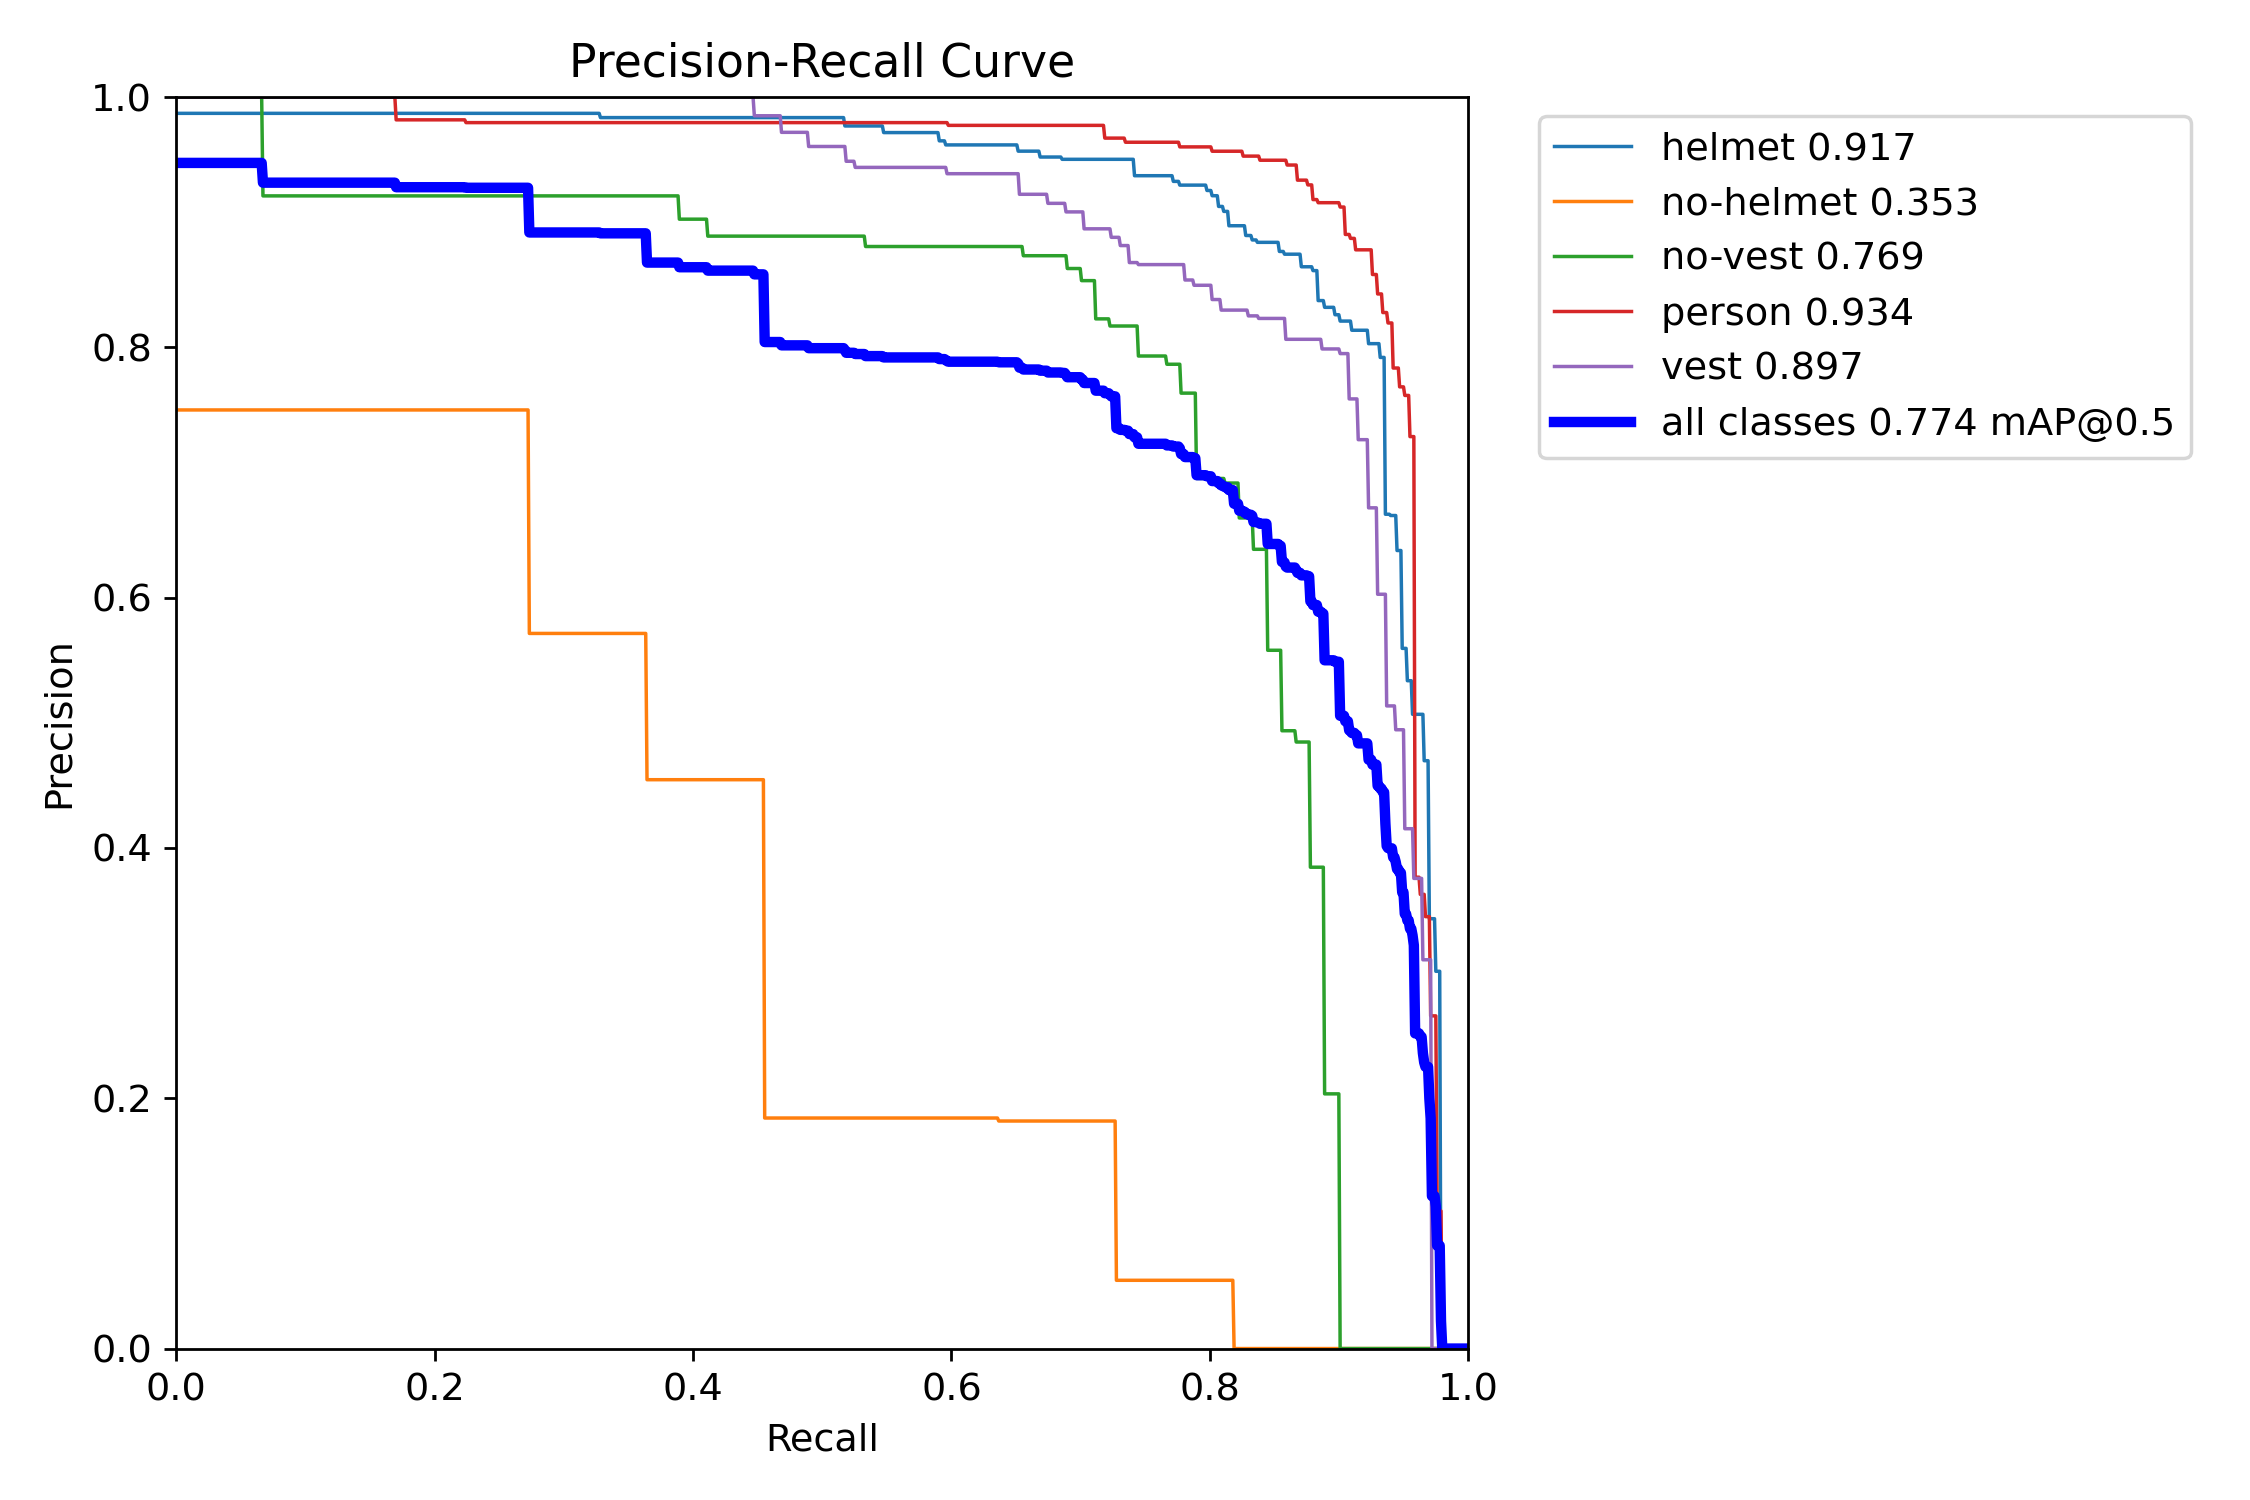


BoxF1_curve.png


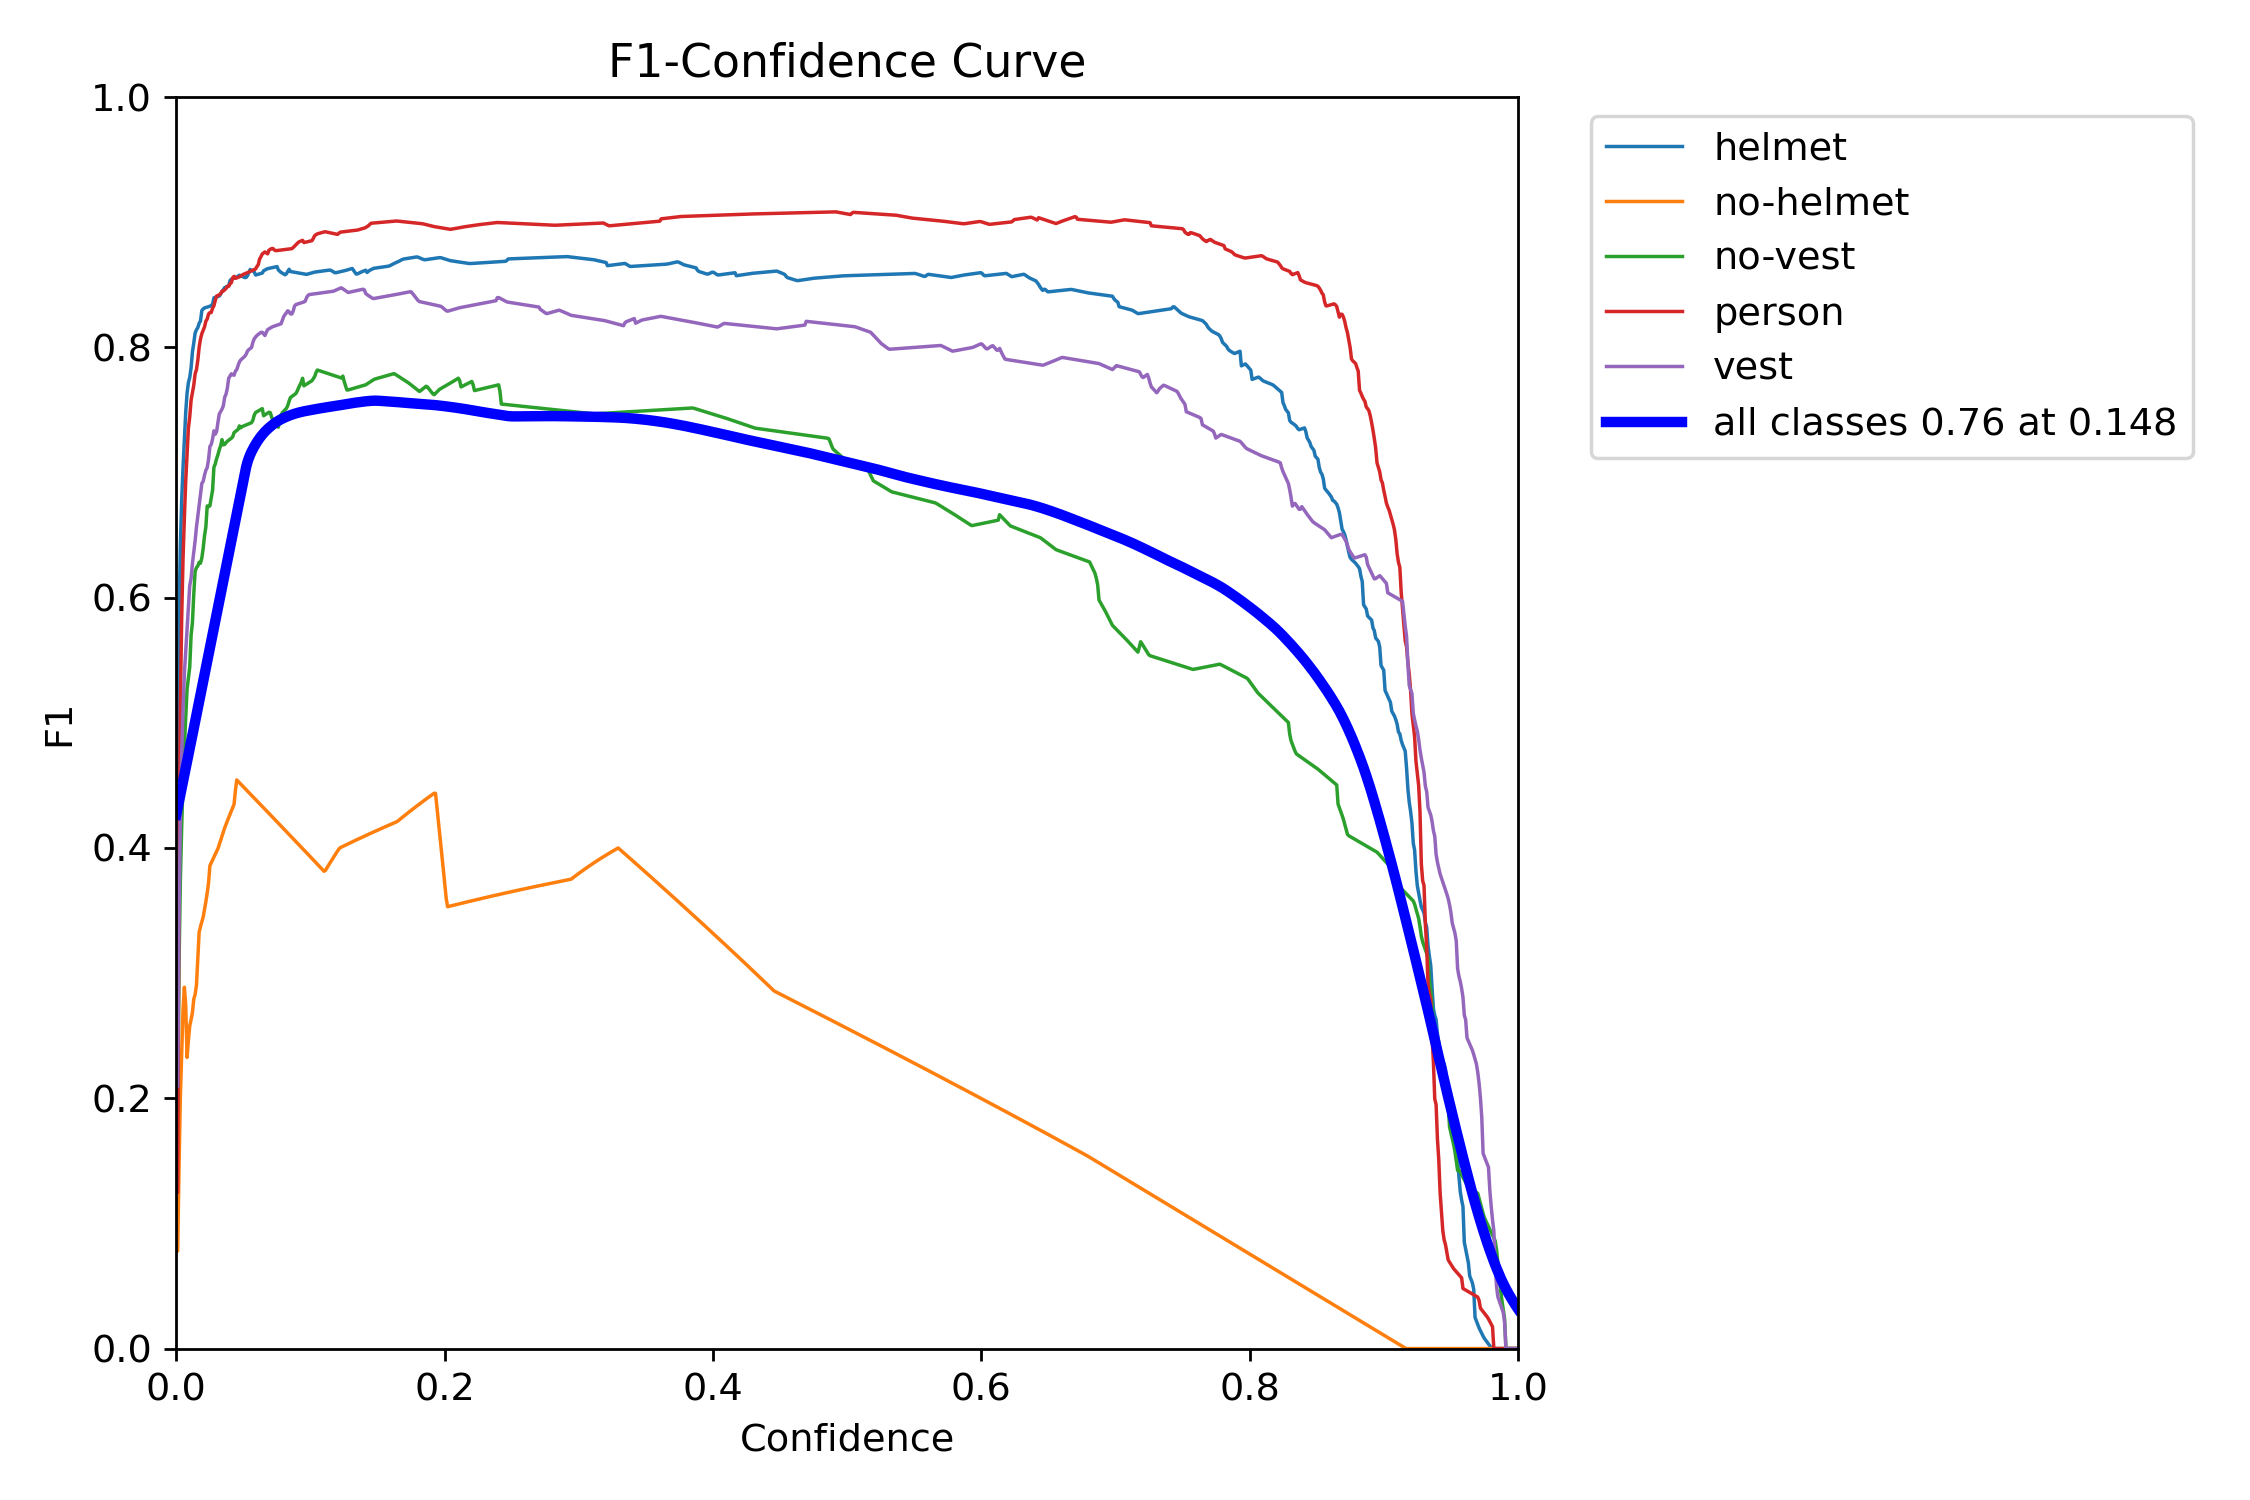

In [10]:
from IPython.display import Image as Tampil, display
for f in ["results.png", "confusion_matrix_normalized.png",
          "BoxPR_curve.png", "BoxF1_curve.png"]:
    p = f"{PROJECT}/{RUN}/{f}"
    if os.path.exists(p):
        print("\n" + "=" * 70); print(f)
        display(Tampil(filename=p, width=900))


train_batch0.jpg


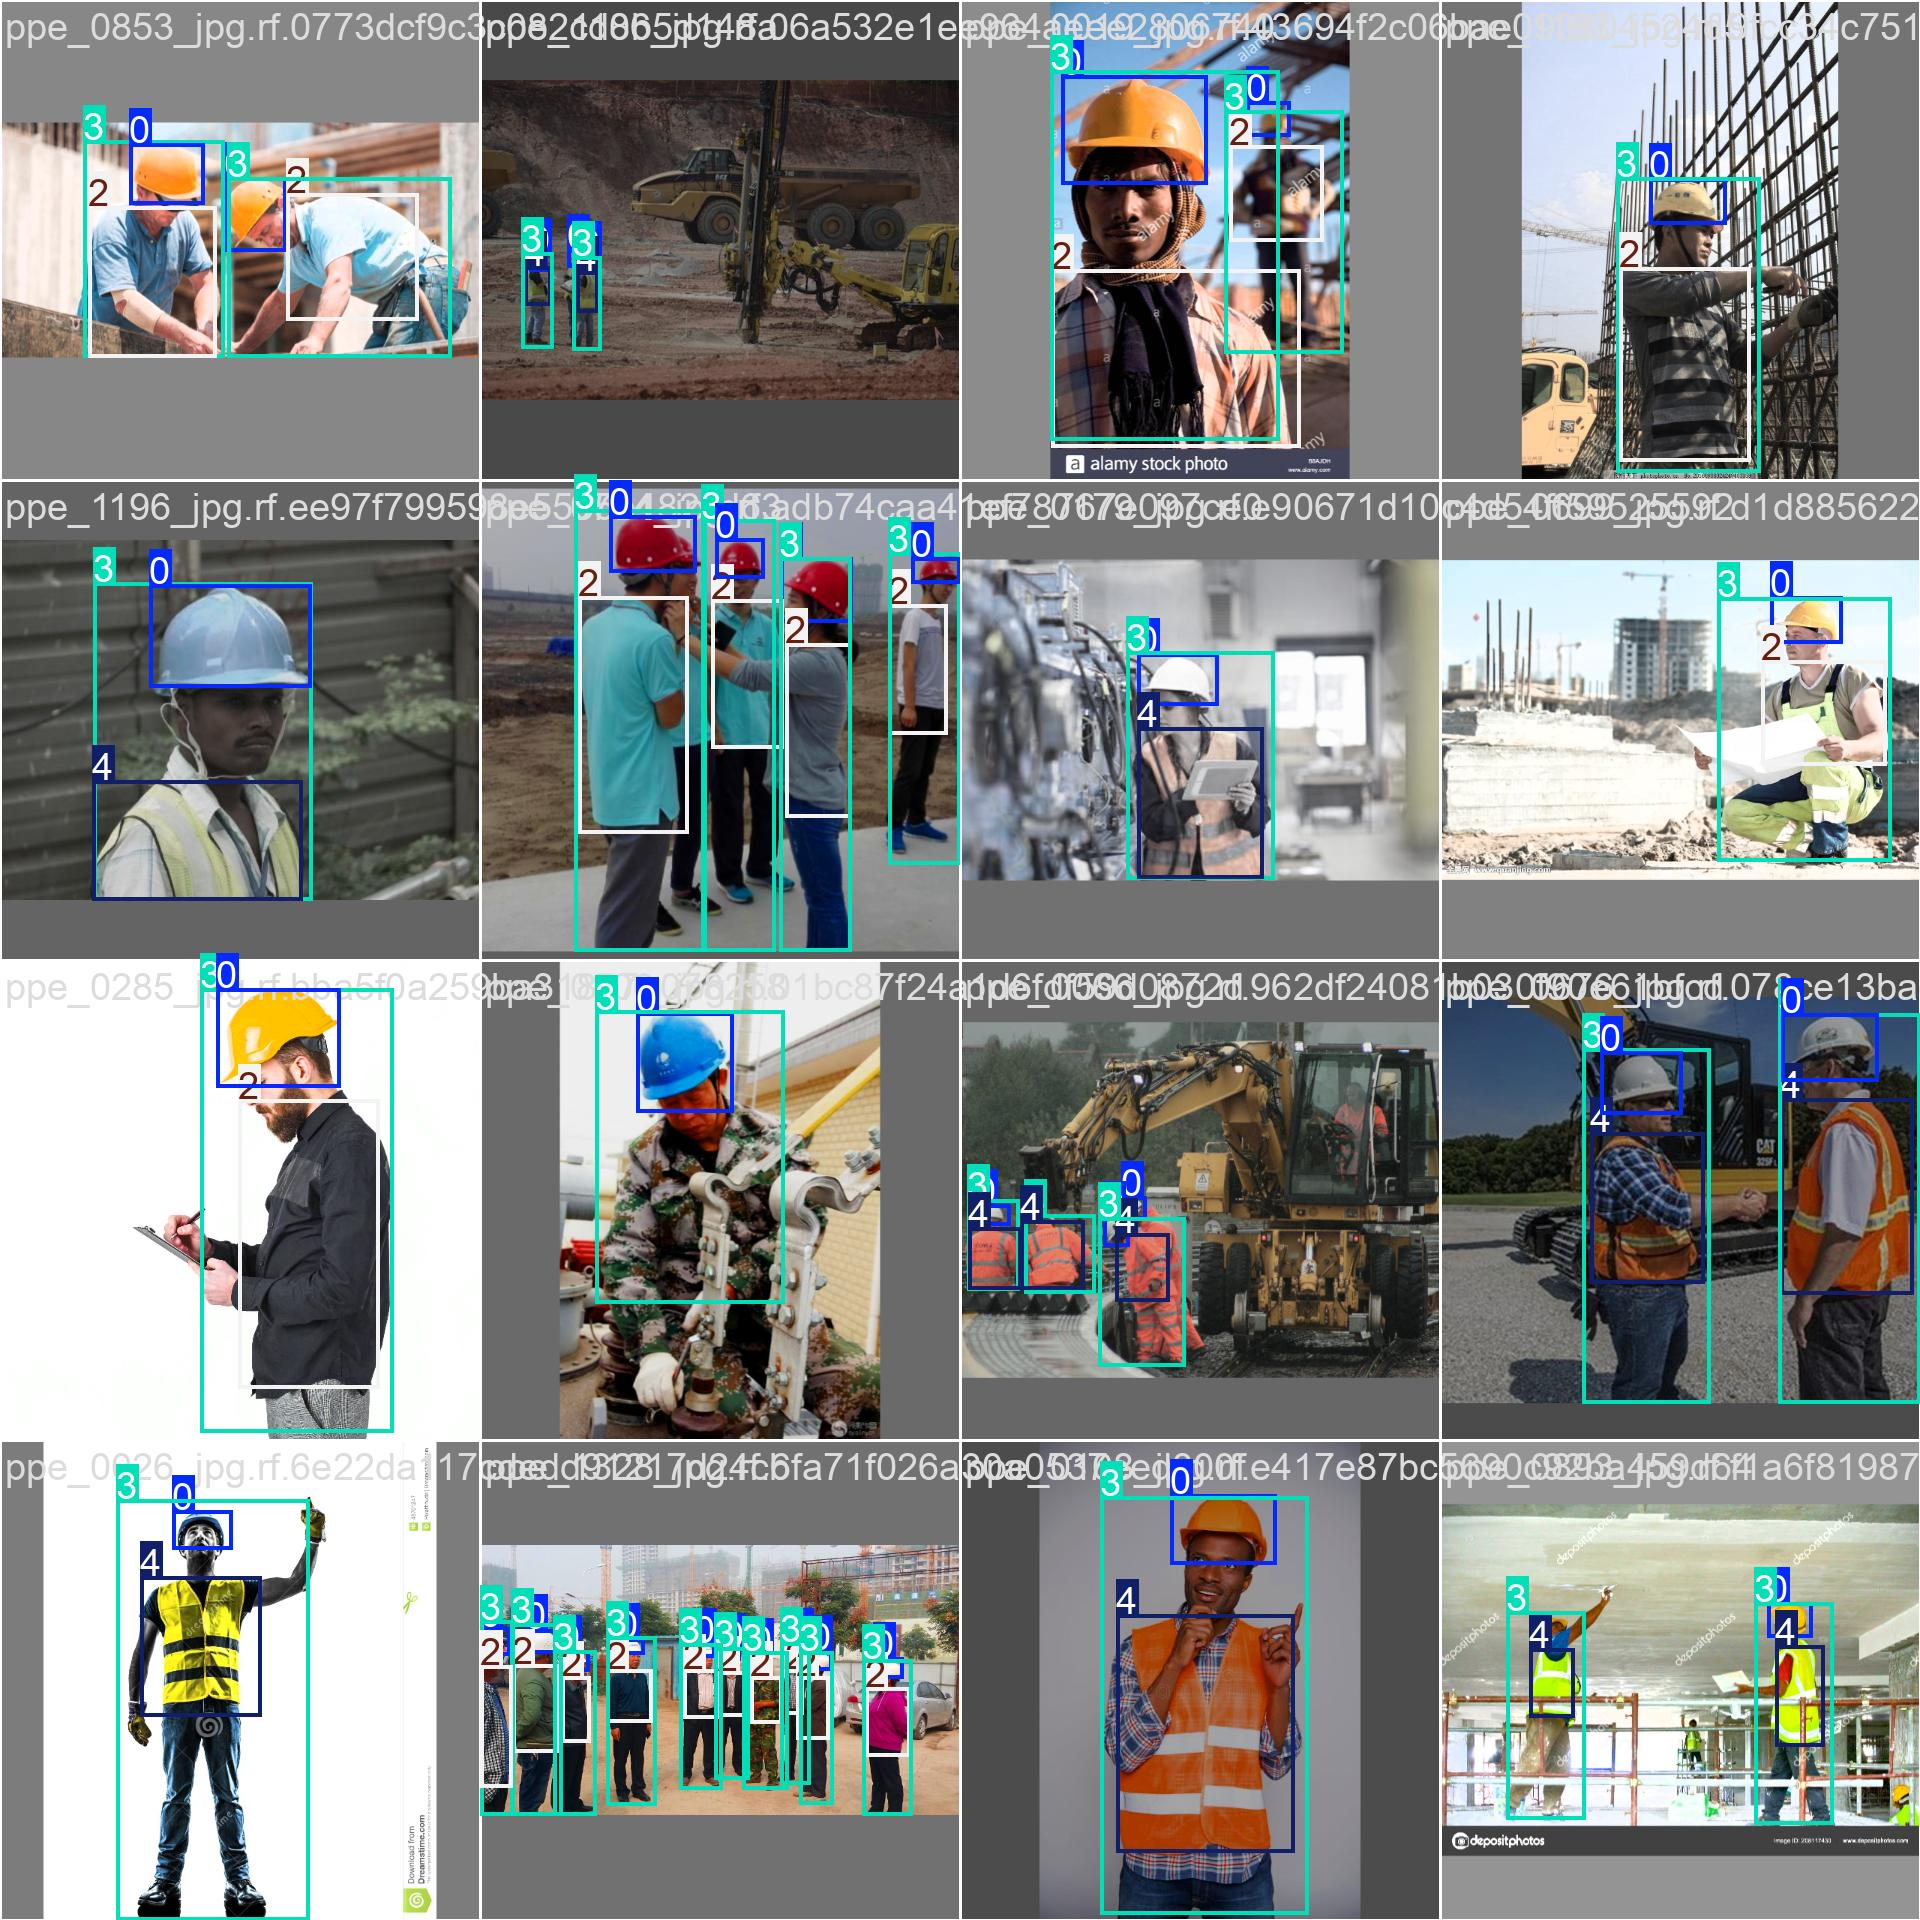


val_batch0_labels.jpg


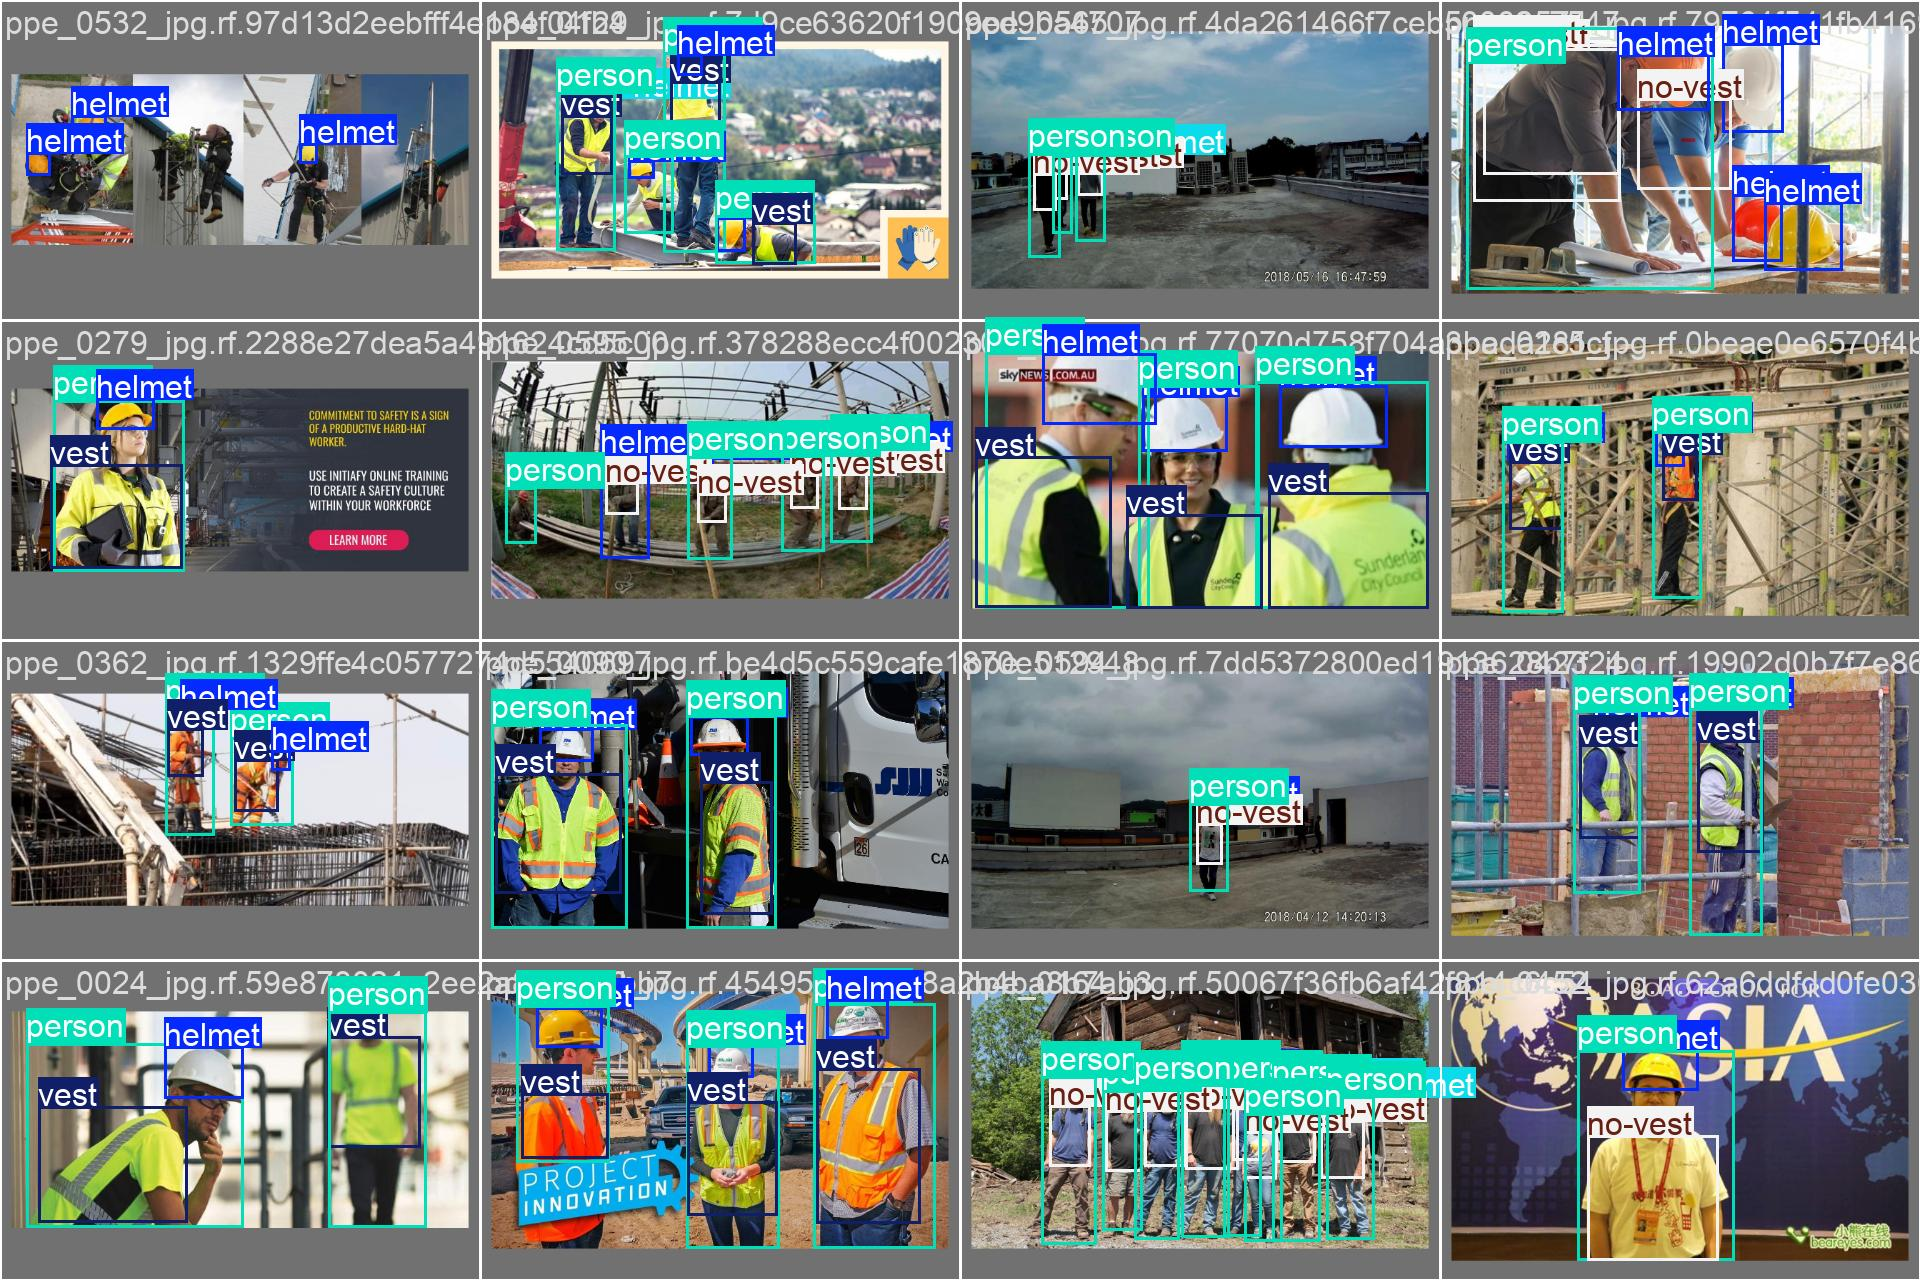


val_batch0_pred.jpg


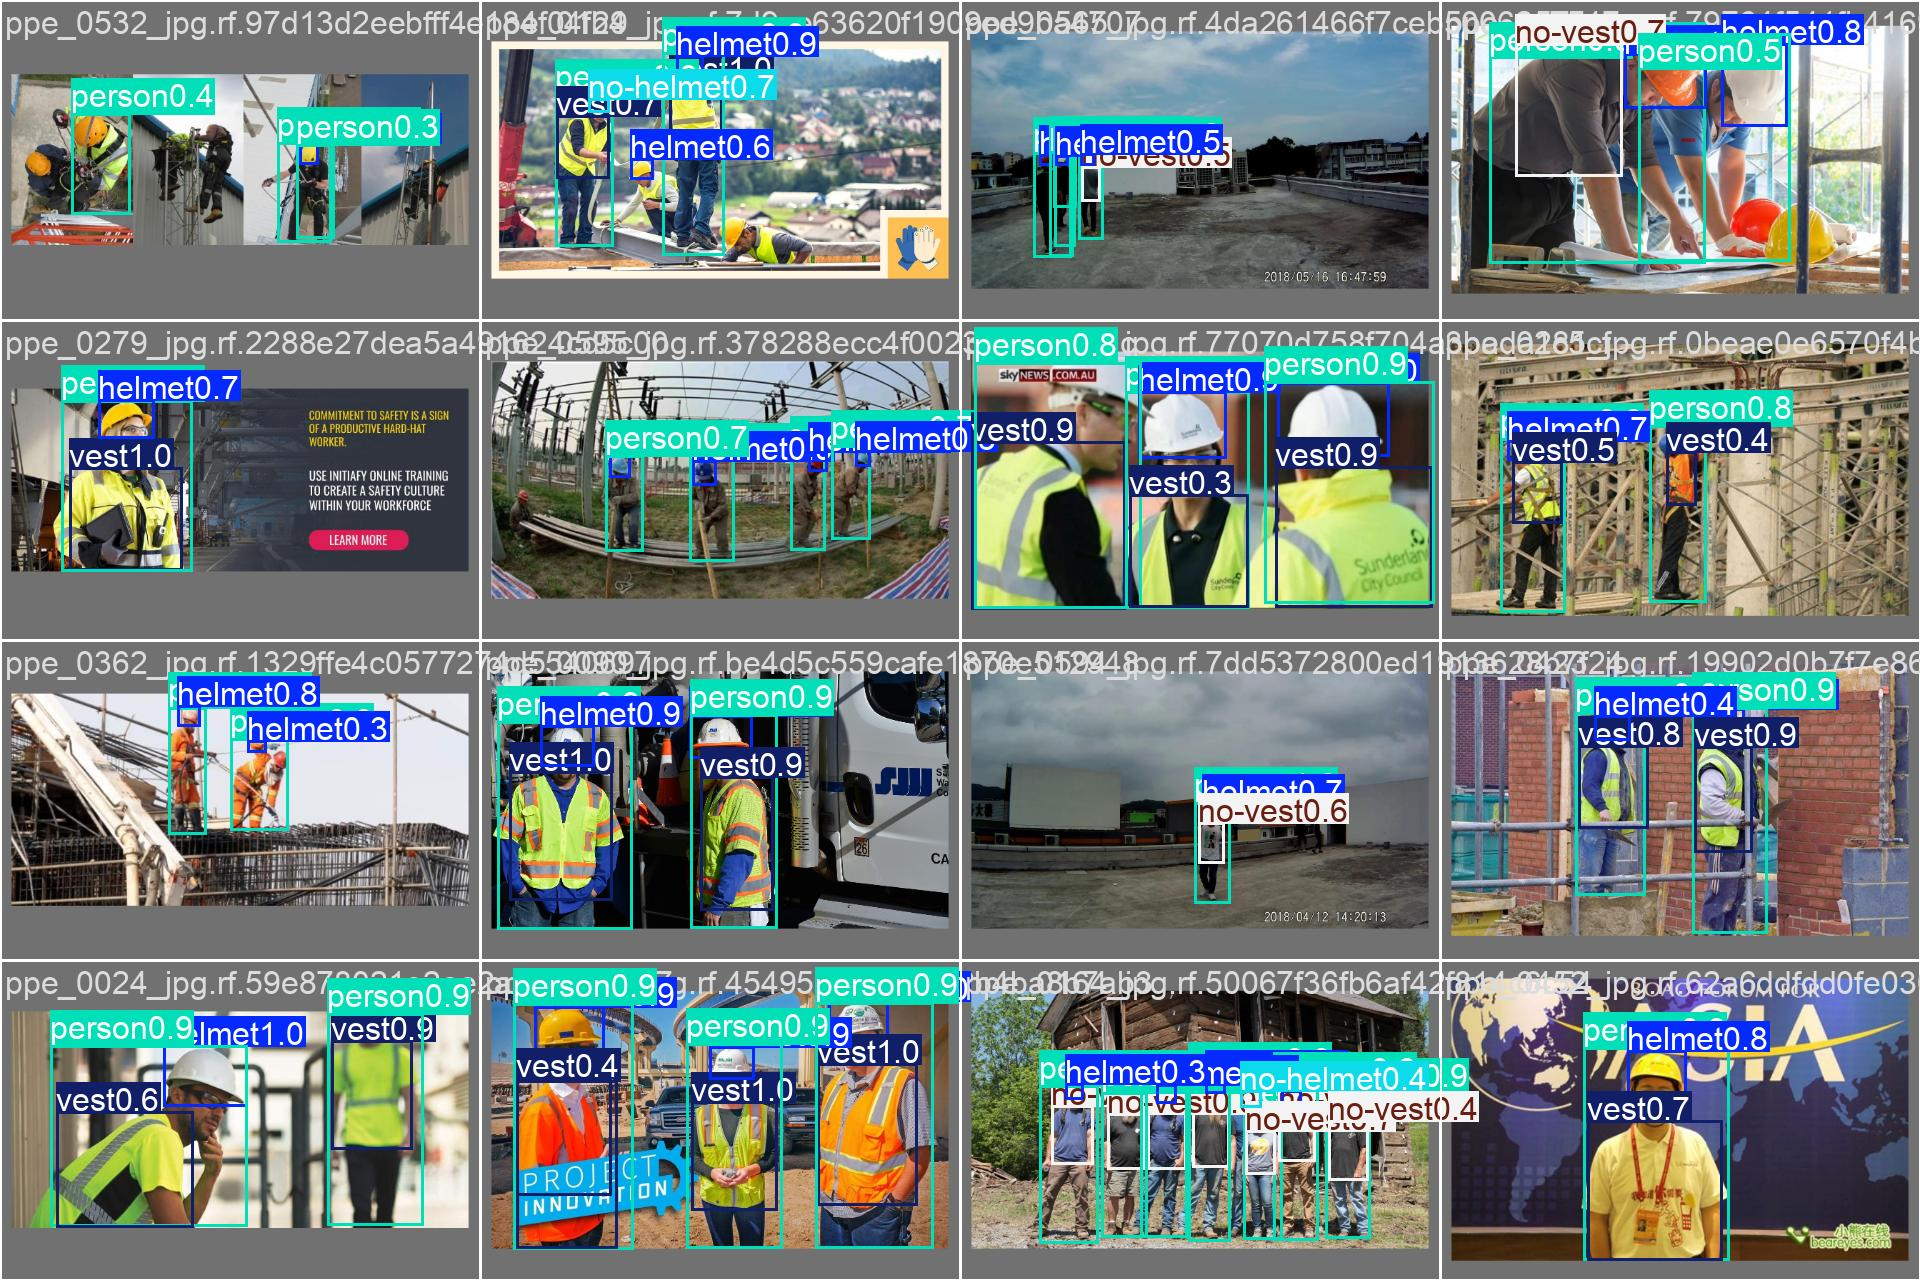

In [11]:
# Gambar batch, cara tercepat mengungkap masalah label.
for f in ["train_batch0.jpg", "val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    p = f"{PROJECT}/{RUN}/{f}"
    if os.path.exists(p):
        print("\n" + "=" * 70); print(f)
        display(Tampil(filename=p, width=900))

## Evaluasi di test set

Dua hal yang harus benar.

**Evaluasi di test, bukan validation.** Validation dipakai untuk memilih
checkpoint, jadi angkanya sudah sedikit menyesuaikan diri. Test set yang tidak
pernah dipakai memutuskan apa pun adalah satu-satunya angka yang jujur.

**`conf=0.001`, bukan bawaan 0,25.** Menghitung mAP dari deteksi yang sudah
dipotong pada 0,25 memutus ekor kurva precision-recall, dan mAP yang dilaporkan
jadi lebih rendah dari yang sebenarnya. Ini salah satu cacat di contoh kode.

In [12]:
best = f"{PROJECT}/{RUN}/weights/best.pt"
model = YOLO(best)

metrik = model.val(data=YAML, split="test", imgsz=640,
                   conf=0.001, iou=0.7, plots=False, verbose=False)

print(f"mAP@0.5       {metrik.box.map50:.4f}")
print(f"mAP@0.5:0.95  {metrik.box.map:.4f}")
print()
print(f"{'kelas':12} {'P':>7} {'R':>7} {'mAP50':>8} {'mAP50-95':>9}")
print("-" * 47)
per_kelas = {}
for i, n in enumerate(metrik.names.values()):
    per_kelas[n] = {"P": round(float(metrik.box.p[i]), 4),
                    "R": round(float(metrik.box.r[i]), 4),
                    "mAP50": round(float(metrik.box.ap50[i]), 4),
                    "mAP50_95": round(float(metrik.box.ap[i]), 4)}
    print(f"{n:12} {metrik.box.p[i]:7.3f} {metrik.box.r[i]:7.3f} "
          f"{metrik.box.ap50[i]:8.3f} {metrik.box.ap[i]:9.3f}")

print()
print("PERHATIAN. Baca baris no-helmet dengan hati-hati. Kelas itu hanya punya")
print("24 instance di test set dan 11 di validation, jadi angkanya rapuh.")
print("Recall-nya dilaporkan terpisah di README, bukan disembunyikan di mAP.")

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1960.9±478.1 MB/s, size: 126.0 KB)
val: Scanning /content/dataset/test/labels... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 1.1Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.1it/s 2.9s
                   all         90        623      0.823      0.657      0.722       0.37
Speed: 1.9ms preprocess, 15.8ms inference, 0.0ms loss, 3.9ms postprocess per image
mAP@0.5       0.7224
mAP@0.5:0.95  0.3704

kelas              P       R    mAP50  mAP50-95
-----------------------------------------------
helmet         0.867   0.837    0.876     0.433
no-helmet      0.793   0.333    0.421     0.182
no-vest        0.731   0.607    0.65

In [13]:
# Kecepatan. Model akurat yang terlalu lambat tetap bukan model yang benar.
import numpy as np
from PIL import Image
contoh = sorted(glob.glob(f"{ROOT}/test/images/*"))[:1][0]
im = Image.open(contoh).convert("RGB")

model(im, verbose=False)                       # pemanasan
t = time.time()
for _ in range(20):
    r = model(im, verbose=False)[0]
ms = (time.time() - t) / 20 * 1000

print("di", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print(r.speed)
print(f"{ms:.1f} ms per gambar  ({1000/ms:.1f} FPS)")
print()
print("Angka ini di GPU Colab. Aplikasi berjalan di CPU, jadi jauh lebih lambat.")
print("Yang dilaporkan nanti angka di perangkat tempat aplikasi benar-benar jalan.")

di Tesla T4
{'preprocess': 2.0644619999075076, 'inference': 22.295671999927436, 'postprocess': 3.4646730000531534}
28.2 ms per gambar  (35.5 FPS)

Angka ini di GPU Colab. Aplikasi berjalan di CPU, jadi jauh lebih lambat.
Yang dilaporkan nanti angka di perangkat tempat aplikasi benar-benar jalan.


## Menyimpan model dan mencatat versi

Dua hal disimpan, bobotnya dan lingkungan yang menghasilkannya. Yang kedua sering
dilupakan dan menyebabkan model gagal dimuat di aplikasi.

In [14]:
import subprocess, sys

TUJUAN = "/content/drive/MyDrive/capstone4"
os.makedirs(TUJUAN, exist_ok=True)

nama_bobot = f"apd_{RUN}.pt"
shutil.copy(best, f"{TUJUAN}/{nama_bobot}")

catatan = {
    "run": RUN,
    "model_awal": MODEL_AWAL,
    "imgsz": 640,
    "epochs": args.get("epochs"),
    "batch": args.get("batch"),
    "seed": args.get("seed"),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "python": sys.version.split()[0],
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "ukuran_bobot_mb": round(os.path.getsize(best) / 1e6, 2),
    "map50": round(float(metrik.box.map50), 4),
    "map50_95": round(float(metrik.box.map), 4),
    "per_kelas": per_kelas,
    "augmentasi_geometris_mati": True,
}
with open(f"{TUJUAN}/{RUN}_catatan.json", "w", encoding="utf-8") as f:
    json.dump(catatan, f, ensure_ascii=False, indent=2)

print(json.dumps(catatan, ensure_ascii=False, indent=2))
print()
print(f"bobot   -> {TUJUAN}/{nama_bobot}")
print(f"catatan -> {TUJUAN}/{RUN}_catatan.json")
print()
print("LANGKAH BERIKUTNYA DI KOMPUTER ANDA")
print(f"  1. Unduh {nama_bobot} dari Drive")
print("  2. Taruh di repo sebagai models/apd_baseline.pt")
print(f"  3. Pastikan requirements.txt memakai ultralytics=={ultralytics.__version__}")
print("  4. Salin isi catatan json ini ke README bagian Catatan versi")

# Kalau ingin langsung mengunduh ke komputer:
# from google.colab import files; files.download(best)

{
  "run": "v1_baseline_640",
  "model_awal": "yolo11n.pt",
  "imgsz": 640,
  "epochs": 30,
  "batch": 16,
  "seed": 0,
  "ultralytics": "8.4.138",
  "torch": "2.11.0+cu128",
  "python": "3.13.15",
  "gpu": "Tesla T4",
  "ukuran_bobot_mb": 5.47,
  "map50": 0.7224,
  "map50_95": 0.3704,
  "per_kelas": {
    "helmet": {
      "P": 0.8671,
      "R": 0.8367,
      "mAP50": 0.8763,
      "mAP50_95": 0.4335
    },
    "no-helmet": {
      "P": 0.7926,
      "R": 0.3333,
      "mAP50": 0.4209,
      "mAP50_95": 0.1821
    },
    "no-vest": {
      "P": 0.7311,
      "R": 0.6066,
      "mAP50": 0.6523,
      "mAP50_95": 0.3131
    },
    "person": {
      "P": 0.865,
      "R": 0.8551,
      "mAP50": 0.8479,
      "mAP50_95": 0.5083
    },
    "vest": {
      "P": 0.858,
      "R": 0.6556,
      "mAP50": 0.8147,
      "mAP50_95": 0.415
    }
  },
  "augmentasi_geometris_mati": true
}

bobot   -> /content/drive/MyDrive/capstone4/apd_v1_baseline_640.pt
catatan -> /content/drive/MyDrive/capstone

## Yang sengaja tidak dikerjakan hari ini

**Bukan model terbaik.** Hanya 30 epoch pada imgsz 640. Kalau mAP-nya rendah,
itu wajar dan bukan alasan menunda deploy.

**Belum ada eksperimen.** Tabel perbandingan run dikerjakan hari 8 sampai 10,
dengan satu perubahan per run.

| Run | Yang diubah | Kapan |
|---|---|---|
| v1_baseline_640 | baseline, geometris mati | hari 3, notebook ini |
| v2_epoch150 | epoch dinaikkan | hari 8 |
| v3_imgsz960 | v2 plus resolusi naik | hari 9 |
| v4_copypaste | v3 plus penanganan kelas langka | hari 9 |
| v5_dengan_mosaic | pembanding, mosaic dinyalakan | hari 10 |

Run terakhir dipakai untuk menunjukkan berapa mAP yang dikorbankan demi patuh
pada instruksi SOAL. Itu bukti pemahaman, bukan pengakuan kalah.

## Sisa hari 3

Setelah bobot ada di `models/`, lanjutkan ke `app.py` dan deploy ke Streamlit
Community Cloud **hari ini juga**. Aplikasinya akan sederhana sekali, dan itu
memang tujuannya. Yang dibuktikan hari ini bukan kualitas aplikasi, melainkan
bahwa jalurnya tembus dari data sampai link publik.